# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** November 14, 2025 <br>
**Objective:** Predict a categorical target and evaluate performance of Decision Tree, Support Vector Machine and Neural Network classifiers.


## Introduction
In this project, we use the Titanic dataset to build and evaluate three classifiers: Decision Tree, Support Vector Machine, and Neural Network. We compare model performance across three different feature sets and reflect on their effectiveness for predicting passenger survival.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures


## Section 1. Load and Inspect the Data

Next, we load the Titanic dataset from seaborn and view its head.

In [99]:
titanic_df: pd.DataFrame = sns.load_dataset("titanic")
titanic_df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Section 2. Data Exploration and Preparation

We impute missing values for 'age' using the median, binary encode 'sex', and drop the rows with missing fare.  Then, we add the feature 'family_size', number of family members on board, by counting sibsp (number of siblings or spouses on board), parch (number of parents or children on board), and 1 to count the individual. Finally, we binary encode 'sex'.

In [100]:
median_age = titanic_df["age"].median()
titanic_df["age"] = titanic_df["age"].fillna(median_age)

titanic_df["sex"] = titanic_df["sex"].map({"male": 1, "female": 0})

titanic_df = titanic_df.dropna(subset=["fare"])

titanic_df["family_size"] = titanic_df["sibsp"] + titanic_df["parch"] + 1

## Section 3. Feature Selection and Justification

With regression in mind, we now select input and target features for our model.  We will consider the following four different cases for our models:

In [101]:
# Case 1: age
X1 = titanic_df[["age"]]
y1 = titanic_df["fare"]

# Case 2: family_size
X2 = titanic_df[["family_size"]]
y2 = titanic_df["fare"]

# Case 3: age and family size
X3 = titanic_df[["age", "family_size"]]
y3 = titanic_df["fare"]

# Case 4: sex
X4 = titanic_df[["sex"]]
y4 = titanic_df["fare"]

Reflection 3:

1) Why might these features affect a passenger’s fare:
2) List all available features:
3) Which other features could improve predictions and why:
4) How many variables are in your Case 4:
5) Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs: 

## Section 4. Train a Regression Model (Linear Regression)

In this section, we will train an Ordinary Least Squares Regression Model.

### 4.1 Split the Data

First, we split our data for each case.

In [102]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

### 4.2 Train, Predict, and Report Linear Regression Models (all 4 cases)

We now train and predict each model, then give a performance report.

In [103]:
linear_dict: dict = {
    "Case 1: Age": (X1_train, X1_test, y1_train, y1_test),
    "Case 2: Family Size": (X2_train, X2_test, y2_train, y2_test),
    "Case 3: Age + Family Size": (X3_train, X3_test, y3_train, y3_test),
    "Case 4: Sex": (X4_train, X4_test, y4_train, y4_test)
}

linear_y_pred_test: dict = {}
width: int = 12

for case, (X_train, X_test, y_train, y_test) in linear_dict.items():

    lr_model = LinearRegression().fit(X_train, y_train)
    y_pred_train = lr_model.predict(X_train)
    linear_y_pred_test[case] = lr_model.predict(X_test)

    print(f"{case}")
    print("-"*len(case))
    print(f"{'Training R²:':<{width}} {r2_score(y_train, y_pred_train):>.4f}")
    print(f"{'Test R²:':<{width}} {r2_score(y_test, linear_y_pred_test[case]):>.4f}")
    print(f"{'Test RMSE:':<{width}} {root_mean_squared_error(y_test, linear_y_pred_test[case]):>.4f}")
    print(f"{'Test MAE:':<{width}} {mean_absolute_error(y_test, linear_y_pred_test[case]):>.4f}\n")

Case 1: Age
-----------
Training R²: 0.0100
Test R²:     0.0034
Test RMSE:   37.9716
Test MAE:    25.2864

Case 2: Family Size
-------------------
Training R²: 0.0499
Test R²:     0.0222
Test RMSE:   37.6115
Test MAE:    25.0253

Case 3: Age + Family Size
-------------------------
Training R²: 0.0735
Test R²:     0.0498
Test RMSE:   37.0778
Test MAE:    24.2849

Case 4: Sex
-----------
Training R²: 0.0239
Test R²:     0.0994
Test RMSE:   36.0975
Test MAE:    24.2425



### Reflection 4:

Compare the train vs test results for each.

1) Did Case 1 overfit or underfit? Explain:
2) Did Case 2 overfit or underfit? Explain:
3) Did Case 3 overfit or underfit? Explain:
4) Did Case 4 overfit or underfit? Explain:

Adding Age

1) Did adding age improve the model:
2) Propose a possible explanation (consider how age might affect ticket price, and whether the data supports that): 

Worst

1) Which case performed the worst:
2) How do you know: 
3) Do you think adding more training data would improve it (and why/why not): 

Best

1) Which case performed the best:
2) How do you know: 
3) Do you think adding more training data would improve it (and why/why not): 

## Section 5. Compare Alternative Models

In this section, we will take the second best-performing case and explore other regression models, since our best performing case, Case 4: Sex, is not appropriate for the Polynomial Cubic Fit Model.

### 5.1 Ridge Regression (L2 Penalty)

Now, we train and predict a Ridge Regression Model for Case 3: Age + Family Size.

In [104]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X3_train, y3_train)
y_pred_ridge = ridge_model.predict(X3_test)

### 5.2 Elastic Net (L1 + L2 combined)

Then, we train and predict an Elastic Net Regression Model for Case 3: Age + Family Size.

In [105]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X3_train, y3_train)
y_pred_elastic = elastic_model.predict(X3_test)

### 5.3 Polynomial Regression

Next, we train and predict a Polynomial Cubic Fit Model for Case 3: Age + Family Size.

In [106]:
# Set up the poly inputs
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X3_train)
X_test_poly = poly.transform(X3_test)

# Use the poly inputs in the LR model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y3_train)
y_pred_poly = poly_model.predict(X_test_poly)

### 5.4 Visualize Polynomial Cubic Fit

Now, we visualize our Polynomial Cubic Fit Model for Case 3: Age + Family Size.

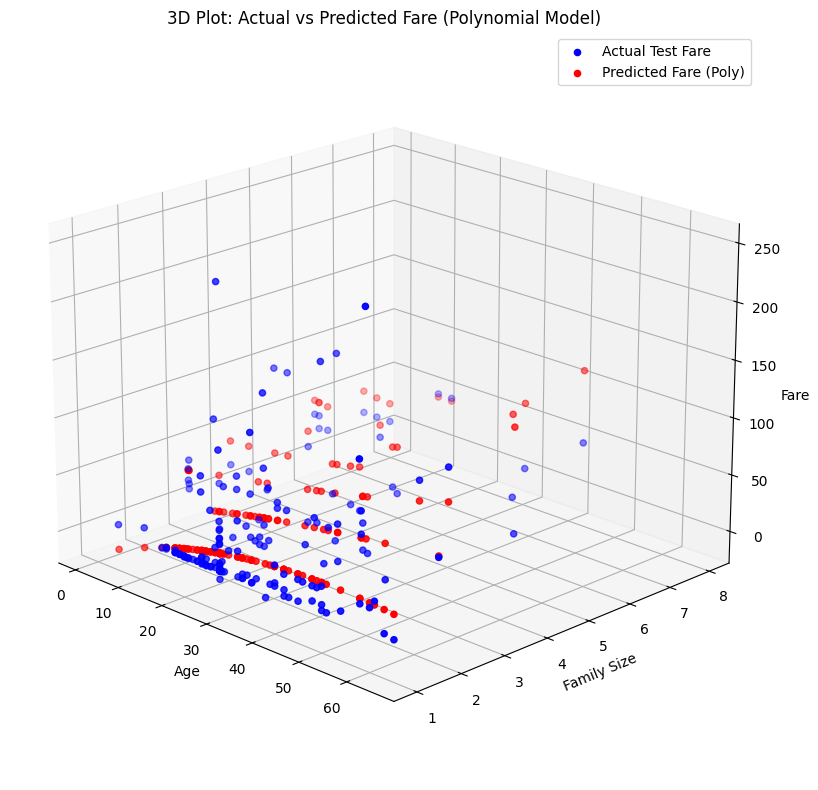

In [164]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot 1: Actual Test Data
ax.scatter(X3_test.iloc[:, 0], X3_test.iloc[:, 1], y3_test,
           color="blue", label="Actual Test Fare")

# Plot 2: Predicted Data points (same X values, different Y values)
ax.scatter(X3_test.iloc[:, 0], X3_test.iloc[:, 1], y_pred_poly, # <-- Use y_pred_poly
           color="red", label="Predicted Fare (Poly)")

ax.set_xlabel("Age")
ax.set_ylabel("Family Size")
ax.set_zlabel("Fare")
ax.set_title("3D Plot: Actual vs Predicted Fare (Polynomial Model)")
ax.legend()
ax.view_init(elev=20, azim=ax.azim+15)
fig.text(x=0.92, y=0.5, s=" ")
plt.tight_layout()
plt.show()

At this point, we tune hyperparameters.

In [ ]:
scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)

smote = SMOTE(random_state=42)
X3_train_bal, y3_train_bal = smote.fit_resample(X3_train_scaled, y3_train)

NameError: name 'StandardScaler' is not defined

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Best parameters found: {'activation': 'relu', 'alpha': np.float64(0.000774263682681127), 'batch_size': 64, 'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV score: 0.6327729222823641


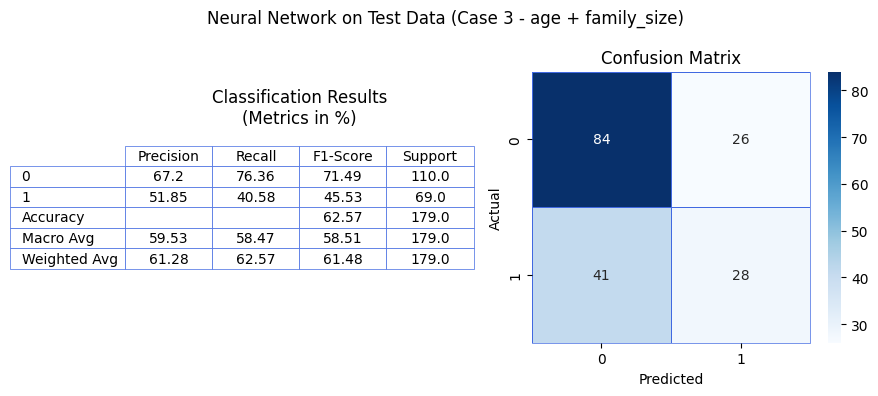

In [ ]:
# CAUTION: Long run time!

nn_model_tune = MLPClassifier(
    max_iter=1000,
    random_state=42
)

parameter_space = {
    "hidden_layer_sizes": [(20,), (50,), (100,), (20,10), (50, 25), (100, 50), (50, 25, 10), (20, 10, 5)],
    "activation": ["tanh", "relu"],
    "solver": ["adam"],
    "alpha": np.logspace(-4,0,10),
    "learning_rate_init": [0.001, 0.01, .1],
    "batch_size": [32, 64, 128]
}

clf = GridSearchCV(nn_model_tune, parameter_space, n_jobs=-1, cv=5, verbose=1, scoring="f1_weighted")
clf.fit(X3_train, y3_train) #bal

best_model = clf.best_estimator_
print("Best parameters found:", clf.best_params_)
print("Best CV score:", clf.best_score_)

y3_best_pred = best_model.predict(X3_test)

fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize=(9, 4))

classification_table(y3_test, y3_best_pred, axes[0])
axes[0].set_title("Classification Results\n(Metrics in %)", y=0.78)

cm_nn3 = confusion_matrix(y3_test, y3_best_pred)
sns.heatmap(cm_nn3, annot=True, cmap="Blues", ax=axes[1],
                  linewidths=.5, linecolor="royalblue")
axes[1].patch.set_edgecolor("royalblue")
axes[1].patch.set_linewidth(0.5)
axes[1].set(xlabel="Predicted", ylabel="Actual", title="Confusion Matrix")

fig.suptitle("Neural Network on Test Data (Case 3 - age + family_size)")
plt.tight_layout()
plt.show()

### Reflection 5:
1) How well did each of these new models/cases perform?

    Overall, the model trained with the neural network performed better than the SVC trained models.  The accuracy and weighted average metrics ranged from 64.83% to 66.48% for the neural network on Case 3, contrast to 52.14% to 66.12% for the RBF kernel of the SVC model for Case 3.

    
2) Are there any surprising results or insights?

    The neural network had a disproportionate recall, 82.73% for non-survivors and 40.58% for survivors, indicating the model was struggling to identify survivors. This is likely due to the class imbalance of the target feature of the dataset, where we had 549 non-survivors versus 342 survivors. 

3) Why might one model outperform the others?

    SVC models may outperform Neural Network on small to medium size datasets, especially those with relatively high feature to sample ratio where they are known to accel at maximizing margins.  While the neural networks hierarchical feature learning through layers tends to perform better on larger datasets with a lower feature to sample ratio to avoid overfitting during parameter tuning.

## Section 6. Final Thoughts & Insights


- Findings Summary:

| Model Type | Case | Features Used | Accuracy | Precision | Recall | F1-Score |
|------------|------|---------------|----------|-----------|--------|-----------|
| Decision Tree | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                   | Case 2 | age | 61.45% | 56.61% | 53.24% | 49.88% |
|                   | Case 3 | age + family_size | 59.22% | 57.47% | 59.22% | 57.82% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (RBF Kernel)| Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 63.13% | 66.12% | 63.13% | 52.14% |
|                    | Case 3 | age + family_size | 63.13% | 66.12% | 63.13% | 52.14% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Linear Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 45.25% | 51.17% | 45.25% | 44.68% |
|                    | Case 3 | age + family_size | 45.25% | 50.90% | 45.25% | 44.86% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Poly Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 38.55% | 45.38% | 38.55% | 25.05% |
|                    | Case 3 | age + family_size | 42.46% | 60.34% | 42.46% | 32.32% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| SVM (Sigmoid Kernel) | Case 1 | alone | 62.57% | 63.58% | 62.57% | 62.92% |
|                    | Case 2 | age | 53.63% | 53.25% | 53.63% | 53.43% |
|                    | Case 3 | age + family_size | 54.75% | 55.36% | 54.75% | 55.01% |
|-------------------|------|---------------|----------|-----------|--------|-----------|
| Neural Network (MLP) | Case 3 | age + family_size | 66.48% | 65.33% | 66.48% | 64.83% |

(Weighted averages reported for Precision, Recall, and F1_Score due to significant class imbalance of the target feature (342-549))

- Challenges faced:

    The overall workflow went smooth overall, with the only drawback being the amount of time to process hyperparameter tuning runs.

- Next steps to gain more insights and/or to explore classification models:

    Going forward, training models on more input features and tuning hyperparameters of the current models should prove beneficial in gaining more insights of the dataset. Training neural networks with a different API could also prove more efficient and possibly yield stronger performance due to GPU utilization.